In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns

from pylab import mpl
# 设置显示中文字体
mpl.rcParams["font.sans-serif"] = ["SimHei"]
# 设置正常显示符号
mpl.rcParams["axes.unicode_minus"] = False

# 获取数据


In [121]:
file_data = pd.read_csv("./data/链家北京租房数据.csv")
file_data

,区域,小区名称,户型,面积(㎡),价格(元/月)
0,东城,万国城MOMA,1室0厅,59.11平米,10000
1,东城,北官厅胡同2号院,3室0厅,56.92平米,6000
2,东城,和平里三区,1室1厅,40.57平米,6900
3,东城,菊儿胡同,2室1厅,57.09平米,8000
4,东城,交道口北二条35号院,1室1厅,42.67平米,5500
...,...,...,...,...,...
8218,顺义,怡馨家园,3室1厅,114.03平米,5500
8219,顺义,旭辉26街区,4房间2卫,59平米,5000
8220,顺义,前进花园玉兰苑,3室1厅,92.41平米,5800
8221,顺义,双裕小区,2室1厅,71.81平米,4200


In [122]:
file_data.shape

(8223, 5)

In [123]:
file_data.info()
"""
通过 file_data.info()，我们可以快速确认：
数据总行数和列数；
每一列的名称、是否存在缺失值；
每一列的数据类型是否符合预期（例如面积应为数值型而非字符串）；
整体内存占用情况。
"""

<class 'pandas.DataFrame'>
RangeIndex: 8223 entries, 0 to 8222
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   区域       8223 non-null   str  
 1   小区名称     8223 non-null   str  
 2   户型       8223 non-null   str  
 3   面积(㎡)    8223 non-null   str  
 4   价格(元/月)  8223 non-null   int64
dtypes: int64(1), str(4)
memory usage: 643.4 KB


'\n通过 file_data.info()，我们可以快速确认：\n数据总行数和列数；\n每一列的名称、是否存在缺失值；\n每一列的数据类型是否符合预期（例如面积应为数值型而非字符串）；\n整体内存占用情况。\n'

In [124]:
file_data.describe()

,价格(元/月)
count,8223.000000
mean,9512.297823
std,9186.752612
min,566.000000
25%,4800.000000
50%,6800.000000
75%,10000.000000
max,150000.000000


# 数据基本处理


## 重复值和空值处理


In [125]:
# 重复值
# file_data.duplicated()

file_data = file_data.drop_duplicates()

In [126]:
file_data.shape

(5773, 5)

In [127]:
# 空值处理
file_data = file_data.dropna()

In [128]:
file_data.shape

(5773, 5)

## 数据转换类型


### 面积数据类型转换


In [129]:
file_data.head()

,区域,小区名称,户型,面积(㎡),价格(元/月)
0,东城,万国城MOMA,1室0厅,59.11平米,10000
1,东城,北官厅胡同2号院,3室0厅,56.92平米,6000
2,东城,和平里三区,1室1厅,40.57平米,6900
3,东城,菊儿胡同,2室1厅,57.09平米,8000
4,东城,交道口北二条35号院,1室1厅,42.67平米,5500


In [130]:
# 单个值实现
file_data["面积(㎡)"].values[0][:-2]

'59.11'

In [131]:
# 使用正则从字符串中提取数字并直接转换为浮点数
file_data["面积(㎡)"] = file_data["面积(㎡)"].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

In [132]:
# 确保面积列为浮点数
file_data["面积(㎡)"] = file_data["面积(㎡)"].astype(float)

In [133]:
file_data.head()

,区域,小区名称,户型,面积(㎡),价格(元/月)
0,东城,万国城MOMA,1室0厅,59.11,10000
1,东城,北官厅胡同2号院,3室0厅,56.92,6000
2,东城,和平里三区,1室1厅,40.57,6900
3,东城,菊儿胡同,2室1厅,57.09,8000
4,东城,交道口北二条35号院,1室1厅,42.67,5500


### 户型表达方式替换


In [134]:
file_data

,区域,小区名称,户型,面积(㎡),价格(元/月)
0,东城,万国城MOMA,1室0厅,59.11,10000
1,东城,北官厅胡同2号院,3室0厅,56.92,6000
2,东城,和平里三区,1室1厅,40.57,6900
3,东城,菊儿胡同,2室1厅,57.09,8000
4,东城,交道口北二条35号院,1室1厅,42.67,5500
...,...,...,...,...,...
8218,顺义,怡馨家园,3室1厅,114.03,5500
8219,顺义,旭辉26街区,4房间2卫,59.00,5000
8220,顺义,前进花园玉兰苑,3室1厅,92.41,5800
8221,顺义,双裕小区,2室1厅,71.81,4200


In [135]:
house_data = file_data["户型"]
temp_list = []

for i in house_data:
    # print(i)
    new_info = i.replace("房间", "室")
    temp_list.append(new_info)

In [136]:
file_data.loc[:, "户型"] = temp_list

In [137]:
file_data

,区域,小区名称,户型,面积(㎡),价格(元/月)
0,东城,万国城MOMA,1室0厅,59.11,10000
1,东城,北官厅胡同2号院,3室0厅,56.92,6000
2,东城,和平里三区,1室1厅,40.57,6900
3,东城,菊儿胡同,2室1厅,57.09,8000
4,东城,交道口北二条35号院,1室1厅,42.67,5500
...,...,...,...,...,...
8218,顺义,怡馨家园,3室1厅,114.03,5500
8219,顺义,旭辉26街区,4室2卫,59.00,5000
8220,顺义,前进花园玉兰苑,3室1厅,92.41,5800
8221,顺义,双裕小区,2室1厅,71.81,4200


# 图表分析

## 房源数量、位置分布分析


In [138]:
file_data["区域"].unique()

<ArrowStringArray>
[   '东城',    '丰台', '亦庄开发区',    '大兴',    '房山',    '昌平',    '朝阳',    '海淀',
   '石景山',    '西城',    '通州',   '门头沟',    '顺义']
Length: 13, dtype: str

In [139]:
new_df = pd.DataFrame({"区域":file_data["区域"].unique(), "数量":[0]*13})

In [140]:
new_df

,区域,数量
0,东城,0
1,丰台,0
2,亦庄开发区,0
3,大兴,0
4,房山,0
5,昌平,0
6,朝阳,0
7,海淀,0
8,石景山,0
9,西城,0


In [141]:
# 获取每个区域房源数量
area_count = file_data.groupby(by="区域").count()
# area_count

In [142]:
new_df["数量"] = area_count.values
new_df

,区域,数量
0,东城,282
1,丰台,577
2,亦庄开发区,147
3,大兴,362
4,房山,180
5,昌平,347
6,朝阳,1597
7,海淀,605
8,石景山,175
9,西城,442


In [143]:
new_df.sort_values(by="数量", ascending=False)
# https://mzj.beijing.gov.cn/attach/0/%E5%8C%97%E4%BA%AC%E5%B8%82%E5%9F%BA%E7%A1%80%E5%9C%B0%E7%90%86%E5%BA%95%E5%9B%BE(%E5%B8%82%E5%9F%9F)%E6%A0%B7%E5%9B%BE4(16%E5%BC%80).pdf

,区域,数量
6,朝阳,1597
7,海淀,605
1,丰台,577
10,通州,477
9,西城,442
3,大兴,362
5,昌平,347
12,顺义,297
11,门头沟,285
0,东城,282


## 户型数量分析


In [144]:
house_data = file_data["户型"]
house_data.head()

0    1室0厅
1    3室0厅
2    1室1厅
3    2室1厅
4    1室1厅
Name: 户型, dtype: str

In [145]:
def all_house(arr):
    key = np.unique(arr)
    result = {}
    
    for k in key:
        
        mask = (arr == k)
       
        arr_new = arr[mask]
        v = arr_new.size
        result[k] = v
        
    return result    

In [146]:
house_info = all_house(house_data)

In [147]:
house_info

{'0室0厅': 1,
 '1室0卫': 10,
 '1室0厅': 244,
 '1室1卫': 126,
 '1室1厅': 844,
 '1室2厅': 13,
 '2室0卫': 1,
 '2室0厅': 23,
 '2室1卫': 120,
 '2室1厅': 2249,
 '2室2卫': 22,
 '2室2厅': 265,
 '2室3厅': 1,
 '3室0卫': 3,
 '3室0厅': 12,
 '3室1卫': 92,
 '3室1厅': 766,
 '3室2卫': 48,
 '3室2厅': 489,
 '3室3卫': 1,
 '3室3厅': 10,
 '4室1卫': 15,
 '4室1厅': 58,
 '4室2卫': 24,
 '4室2厅': 191,
 '4室3卫': 5,
 '4室3厅': 9,
 '4室5厅': 2,
 '5室0卫': 1,
 '5室0厅': 1,
 '5室1卫': 3,
 '5室1厅': 7,
 '5室2卫': 7,
 '5室2厅': 49,
 '5室3卫': 3,
 '5室3厅': 24,
 '5室4厅': 1,
 '5室5厅': 1,
 '6室0厅': 1,
 '6室1卫': 1,
 '6室1厅': 1,
 '6室2厅': 5,
 '6室3卫': 2,
 '6室3厅': 6,
 '6室4卫': 2,
 '7室1厅': 1,
 '7室2厅': 2,
 '7室3厅': 3,
 '7室4厅': 1,
 '8室4厅': 2,
 '9室1厅': 2,
 '9室2厅': 1,
 '9室5厅': 2}

In [148]:
# 去掉统计数量较少的值
house_data = dict((key, value) for key, value in house_info.items() if value > 50)

In [149]:
show_houses = pd.DataFrame({"户型": [x for x in house_data.keys()],
              "数量": [x for x in house_data.values()]})

In [150]:
show_houses

,户型,数量
0,1室0厅,244
1,1室1卫,126
2,1室1厅,844
3,2室1卫,120
4,2室1厅,2249
5,2室2厅,265
6,3室1卫,92
7,3室1厅,766
8,3室2厅,489
9,4室1厅,58


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23460 (\N{CJK UNIFIED IDEOGRAPH-5BA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21381 (\N{CJK UNIFIED IDEOGRAPH-5385}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21355 (\N{CJK UNIFIED IDEOGRAPH-536B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure

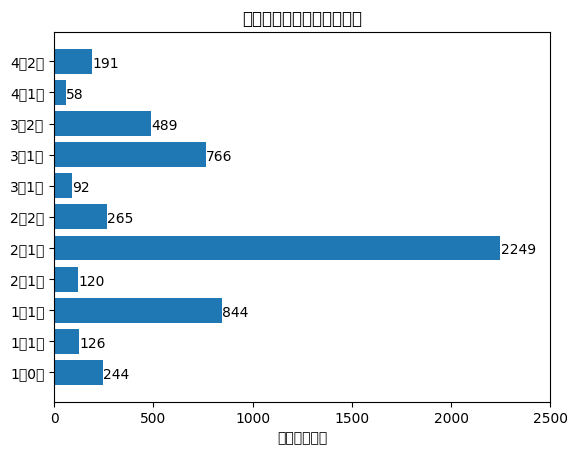

In [151]:
# 图形展示房屋类型

house_type = show_houses["户型"]
house_type_num = show_houses["数量"]

plt.barh(range(11), house_type_num)

plt.yticks(range(11), house_type)
plt.xlim(0, 2500)

plt.title("北京市各区域租房数量统计")
plt.xlabel("房屋房屋类型")

# 给每个条上面添加具体数字
for x, y in enumerate(house_type_num):
    # print(x, y)
    plt.text(y+0.5, x-0.2, "%s" %y)

plt.show()

## 平均租金分析


In [152]:
df_all = pd.DataFrame({"区域": file_data["区域"].unique(),
              "房租总金额": [0]*13,
              "总面积": [0]*13})

In [153]:
df_all

,区域,房租总金额,总面积
0,东城,0,0
1,丰台,0,0
2,亦庄开发区,0,0
3,大兴,0,0
4,房山,0,0
5,昌平,0,0
6,朝阳,0,0
7,海淀,0,0
8,石景山,0,0
9,西城,0,0


In [154]:
file_data.head()

,区域,小区名称,户型,面积(㎡),价格(元/月)
0,东城,万国城MOMA,1室0厅,59.11,10000
1,东城,北官厅胡同2号院,3室0厅,56.92,6000
2,东城,和平里三区,1室1厅,40.57,6900
3,东城,菊儿胡同,2室1厅,57.09,8000
4,东城,交道口北二条35号院,1室1厅,42.67,5500


In [155]:
sum_price = file_data["价格(元/月)"].groupby(file_data["区域"]).sum()
sum_area = file_data["面积(㎡)"].groupby(file_data["区域"]).sum()

In [156]:
df_all["房租总金额"] = sum_price.values.astype(float)
df_all["总面积"] = sum_area.values.astype(float)

In [157]:
df_all

,区域,房租总金额,总面积
0,东城,3945550.0,27353.99
1,丰台,4404893.0,50922.79
2,亦庄开发区,1318400.0,15995.53
3,大兴,2286950.0,35884.15
4,房山,726750.0,15275.41
5,昌平,2521515.0,35972.92
6,朝阳,20281396.0,166921.72
7,海淀,7279350.0,57210.39
8,石景山,1156500.0,13956.67
9,西城,5636975.0,37141.64


In [158]:
# 计算各个区域每平方米的房租
df_all["每平米租金(元)"] = round(df_all["房租总金额"] / df_all["总面积"], 2)

In [159]:
df_all
# new_df

,区域,房租总金额,总面积,每平米租金(元)
0,东城,3945550.0,27353.99,144.24
1,丰台,4404893.0,50922.79,86.50
2,亦庄开发区,1318400.0,15995.53,82.42
3,大兴,2286950.0,35884.15,63.73
4,房山,726750.0,15275.41,47.58
5,昌平,2521515.0,35972.92,70.09
6,朝阳,20281396.0,166921.72,121.50
7,海淀,7279350.0,57210.39,127.24
8,石景山,1156500.0,13956.67,82.86
9,西城,5636975.0,37141.64,151.77


In [160]:
df_merge = pd.merge(new_df, df_all)

In [161]:
df_merge

,区域,数量,房租总金额,总面积,每平米租金(元)
0,东城,282,3945550.0,27353.99,144.24
1,丰台,577,4404893.0,50922.79,86.50
2,亦庄开发区,147,1318400.0,15995.53,82.42
3,大兴,362,2286950.0,35884.15,63.73
4,房山,180,726750.0,15275.41,47.58
5,昌平,347,2521515.0,35972.92,70.09
6,朝阳,1597,20281396.0,166921.72,121.50
7,海淀,605,7279350.0,57210.39,127.24
8,石景山,175,1156500.0,13956.67,82.86
9,西城,442,5636975.0,37141.64,151.77


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19996 (\N{CJK UNIFIED IDEOGRAPH-4E1C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22478 (\N{CJK UNIFIED IDEOGRAPH-57CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20016 (\N{CJK UNIFIED IDEOGRAPH-4E30}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure

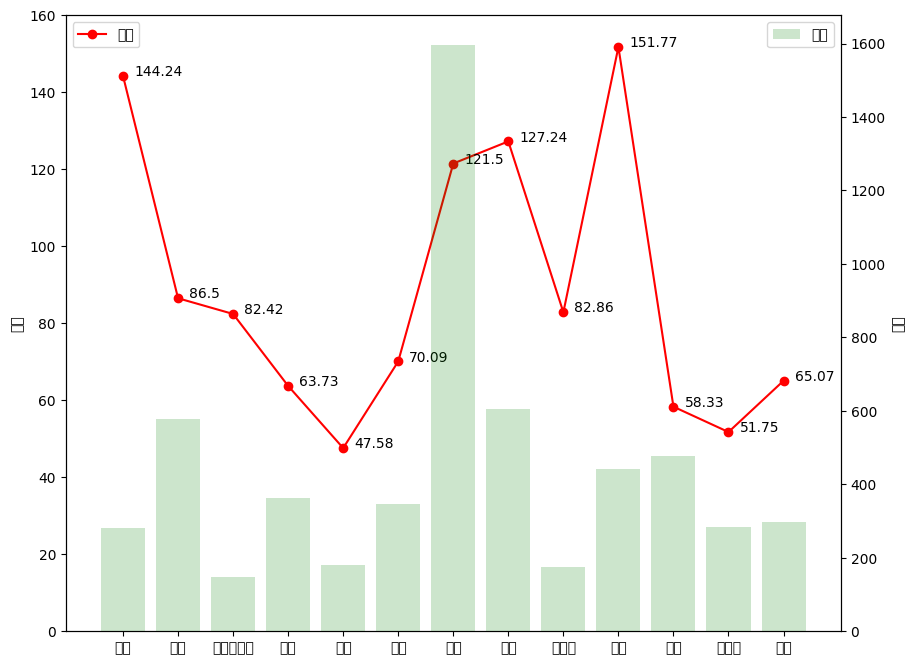

In [162]:
# 图形可视化

num = df_merge["数量"]
price = df_merge["每平米租金(元)"]
lx = df_merge["区域"]
l = [i for i in range(13)]

fig = plt.figure(figsize=(10, 8), dpi=100)

# 显示折线图
ax1 = fig.add_subplot(111)
ax1.plot(l, price, "or-", label="价格")
for i, (_x, _y) in enumerate(zip(l, price)):
    plt.text(_x+0.2, _y, price[i])
ax1.set_ylim([0, 160])   
ax1.set_ylabel("价格")
plt.legend(loc="upper left")

# 显示条形图
ax2 = ax1.twinx()
plt.bar(l, num, label="数量", alpha=0.2, color="green")
ax2.set_ylabel("数量")
plt.legend(loc="upper right")
plt.xticks(l, lx)


plt.show()

## 面积基本分析


In [163]:
# 查看房屋的最大面积和最小面积
print('房屋最大面积是%d平米'%(file_data['面积(㎡)'].max()))
print('房屋最小面积是%d平米'%(file_data['面积(㎡)'].min()))

# 查看房租的最高值和最小值
print('房租最高价格为每月%d元'%(file_data['价格(元/月)'].max()))
print('房屋最低价格为每月%d元'%(file_data['价格(元/月)'].min()))

房屋最大面积是1133平米
房屋最小面积是11平米
房租最高价格为每月150000元
房屋最低价格为每月566元


In [164]:
# 面积划分
area_divide = [1, 30, 50, 70, 90, 120, 140, 160, 1200]
area_cut = pd.cut(list(file_data["面积(㎡)"]), area_divide)
area_cut

[(50, 70], (50, 70], (30, 50], (50, 70], (30, 50], ..., (90, 120], (50, 70], (90, 120], (70, 90], (30, 50]]
Length: 5773
Categories (8, interval[int64, right]): [(1, 30] < (30, 50] < (50, 70] < (70, 90] < (90, 120] < (120, 140] < (140, 160] < (160, 1200]]

In [165]:
area_cut_num = area_cut.describe()
area_cut_num

,counts,freqs
categories,,
"(1, 30]",41,0.007102
"(30, 50]",710,0.122986
"(50, 70]",1566,0.271263
"(70, 90]",1094,0.189503
"(90, 120]",1082,0.187424
"(120, 140]",381,0.065997
"(140, 160]",274,0.047462
"(160, 1200]",625,0.108263


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31859 (\N{CJK UNIFIED IDEOGRAPH-7C73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtool

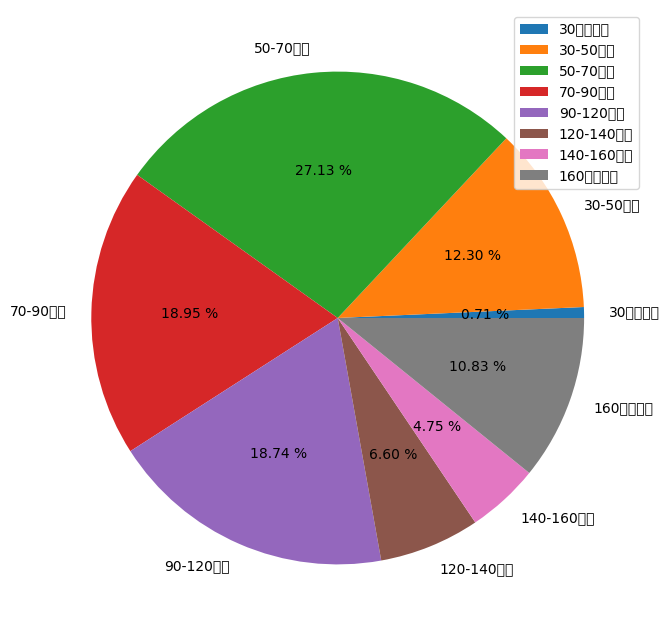

In [166]:
# 图像可视化
area_per = (area_cut_num["freqs"].values)*100

labels  = ['30平米以下', 
           '30-50平米', 
           '50-70平米', 
           '70-90平米',
           '90-120平米',
           '120-140平米',
           '140-160平米',
           '160平米以上']

plt.figure(figsize=(20, 8), dpi=100)
# plt.axes(aspect=1) 
# plt.axis('equal')  # ← 关键！确保饼图为正圆

plt.pie(x=area_per, labels=labels, autopct="%.2f %%")


plt.legend()
plt.show()